In [5]:
# IMPORT
from IPython.display import Image, Math

import os
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from utils import *
import pyagrum as gum
import pyagrum.skbn as skbn
import pyagrum.lib.notebook as gnb
import pyagrum.lib.image as gimg
import pyagrum.lib.dynamicBN as gdyn
import pyagrum.causal as pyc
import pyagrum.causal.notebook as cslnb
from pyagrum.lib.discretizer import Discretizer
import re
import pickle
from sklearn.cluster import KMeans
from scipy.stats import iqr, gaussian_kde, entropy

print(gum.__version__)

2.3.2


In [2]:
def optimal_bins_elbow_method(time_series, min_bins=2, max_bins=15, plot=True):
    """
    Determines the optimal number of bins using the elbow method with KMeans clustering.
    Uses a simple elbow detection without the kneed package.

    Parameters:
    - time_series: numpy array or list of numerical values (1D time series)
    - min_bins: minimum number of bins to consider
    - max_bins: maximum number of bins to consider
    - plot: whether to plot the elbow curve

    Returns:
    - optimal_bins: The optimal number of bins for discretization
    """
    time_series = np.array(time_series).reshape(-1, 1)  # Ensure data is 2D for KMeans

    inertia_values = []
    bin_range = range(min_bins, max_bins + 1)

    for k in bin_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(time_series)
        inertia_values.append(kmeans.inertia_)

    # Simple elbow detection: find point with max second derivative
    inertia_values = np.array(inertia_values)
    first_deriv = np.diff(inertia_values)
    second_deriv = np.diff(first_deriv)
    optimal_idx = np.argmax(second_deriv) + 1
    optimal_bins = list(bin_range)[min(optimal_idx, len(bin_range) - 1)]

    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(bin_range, inertia_values, marker="o", linestyle="-", label="Inertia")
        plt.axvline(optimal_bins, linestyle="--", color="red", label=f"Optimal Bins: {optimal_bins}")
        plt.xlabel("Number of Bins (Clusters)")
        plt.ylabel("Inertia (WCSS)")
        plt.title("Elbow Method for Optimal Bin Selection")
        plt.legend()
        plt.grid(True)
        plt.show()

    return optimal_bins

In [18]:
def find_bin(value, edges):
    """
    Given a continuous value and an array of bin edges,
    return the index of the bin that contains the value.
    """
    idx = np.digitize(value, edges, right=False) - 1
    return int(max(0, min(idx, len(edges) - 2)))

def format_evidence_for_latex(evidence):
    formatted_evidence = []
    
    for var in evidence.keys():
        # Replace the part after the underscore with curly braces, if applicable
        var = re.sub(r'_(\w+)', r'_{\1}', var)  # Add {} around the part after the underscore
        
        # Replace '0' with '_{t-1}'
        var = var.replace('t', '_t')
        var = var.replace('0', '_{t-1}')

        # Append formatted variable to the list
        formatted_evidence.append(f"${var}$")  # Adding $ for LaTeX format
        
    return ', '.join(formatted_evidence)

def get_info(D, auditDict, var):
    if 'param' in auditDict[var] and isinstance(auditDict[var]['param'], list):
        edges = auditDict[var]['param']
        midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
        return auditDict[var]['param'], edges, midpoints
    quantiles = np.linspace(0, 100, auditDict[var]['param'] + 1 if 'param' in auditDict[var] else auditDict[var]['nbBins'] + 1)
    edges = np.percentile(D[var].values, quantiles)
    midpoints = [(edges[i] + edges[i+1]) / 2.0 for i in range(len(edges)-1)]
    return quantiles, edges, midpoints

def loaf_D(indir, bagname):
    print(f"Loading : {bagname}")
    filename = os.path.join(indir, f"{bagname}", f"{bagname}.csv")
    df = pd.read_csv(filename)
    df = df[df['B'] != -1000]
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    
    df = df.drop('B', axis=1)

    
 
    original_names = list(df.columns)
    df.columns = [f'{v}t' for v in original_names]

    # Add lagged variable
    for v in original_names:
        df[f'{v}0'] = np.concatenate([df[f'{v}t'].values[1:], [0]])
    df = df.iloc[1:].reset_index(drop=True)  # Remove first row
    df = df.iloc[:-1].reset_index(drop=True)  # Remove last row
    return df

In [13]:
INDIR = '/home/lcastri/git/causal-sim2real/HRISim_docker/src/HRISim/postprocessing/hrisim_postprocess/csv_pp-1-battery'
test_01 = loaf_D(INDIR, 'test-obs-01')
test_02 = loaf_D(INDIR, 'test-obs-02')
test_03 = loaf_D(INDIR, 'test-obs-03')
test_04 = loaf_D(INDIR, 'test-obs-04')
test_05 = loaf_D(INDIR, 'test-obs-05')
D = test_03
# D = pd.concat([test_01, test_02, test_03, test_04, test_05], ignore_index=True)

Loading : test-obs-01
Loading : test-obs-02
Loading : test-obs-03
Loading : test-obs-04
Loading : test-obs-05



** audit **
- Vt : 
    + method : quantile
    + param : 5
    + type : Continuous
    + minInData : 4.392120448448722e-07
    + maxInData : 0.5251740219044624
- Lt : 
    + method : quantile
    + param : 3
    + type : Continuous
    + minInData : 0.0031967163085937
    + maxInData : 0.1726913452148295
- Ot : 
    + method : NoDiscretization
    + type : Discrete
- V0 : 
    + method : quantile
    + param : 5
    + type : Continuous
    + minInData : 4.392120448448722e-07
    + maxInData : 0.5251740219044624
- L0 : 
    + method : quantile
    + param : 3
    + type : Continuous
    + minInData : 0.0031967163085937
    + maxInData : 0.1726913452148295
- O0 : 
    + method : NoDiscretization
    + type : Discrete


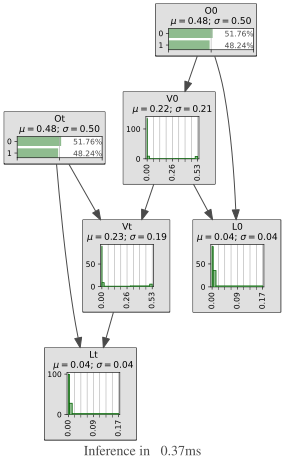

In [14]:
# DISCRETIZATION -- BN CREATION

discretizer=Discretizer(defaultDiscretizationMethod='quantile')
# RVt_bins = optimal_bins_elbow_method(D['R_V0'].values, plot=False)
# ECt_bins = optimal_bins_elbow_method(D['ECt'].values, plot=False)
# discretizer.setDiscretizationParameters('R_V0','quantile', RVt_bins)
# discretizer.setDiscretizationParameters('R_Vt','quantile', RVt_bins)
# discretizer.setDiscretizationParameters('EC0','quantile', ECt_bins)
# discretizer.setDiscretizationParameters('ECt','quantile', ECt_bins)
discretizer.setDiscretizationParameters('V0','quantile', 5)
discretizer.setDiscretizationParameters('Vt','quantile', 5)
discretizer.setDiscretizationParameters('L0','quantile', 3)
discretizer.setDiscretizationParameters('Lt','quantile', 3)

template = discretizer.discretizedTemplate(D)
auditDict=discretizer.audit(D)
print()
print("** audit **")
for var in auditDict:
    print(f"- {var} : ")
    for k,v in auditDict[var].items():
        print(f"    + {k} : {v}")
        
template.addArc("O0", "L0")
template.addArc("O0", "V0")
template.addArc("V0", "L0")
template.addArc("Ot", "Vt")
template.addArc("Ot", "Lt")
template.addArc("Vt", "Lt")
template.addArc("V0", "Vt")
learner = gum.BNLearner(D, template)
learner.useSmoothingPrior()
bn = learner.learnParameters(template)

# time_slices_bn = gdyn.getTimeSlices(bn, size=30)

gnb.showInference(bn)

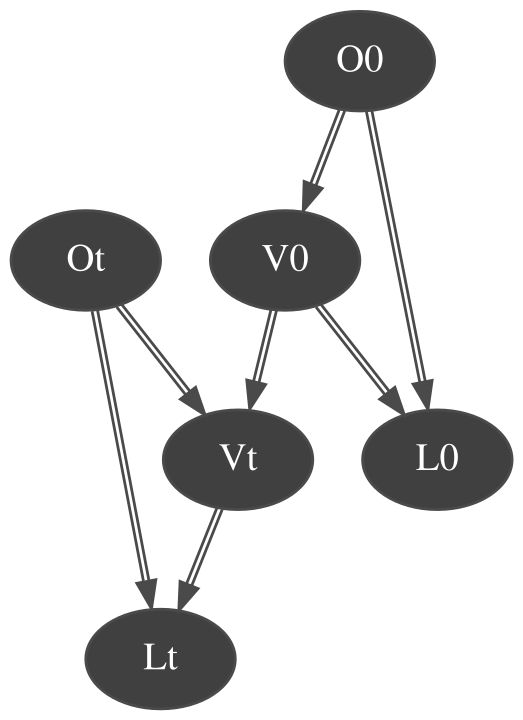

<IPython.core.display.Math object>

In [16]:
cm = pyc.CausalModel(bn)

# ------------------------------
# Evaluate Predictions on a Test Set using BN inference and CausalModel (do-intervention)
# ------------------------------
cslnb.showCausalModel(cm, size="10!")
a = pyc.doCalculusWithObservation(cm,"L0", {"V0"})
display(Math(a.toLatex()))

In [20]:
target_var = 'Lt'
target_var_str = format_evidence_for_latex({target_var: None})
intervention_var = "Vt"

static_duration = 5
dynamic_duration = 4
charging_time = 2
LOAD_FACTOR = 5
ROBOT_MAX_VEL = 0.5
K_nl_s = 100 / (static_duration * 3600)
K_nl_d = (100 / (dynamic_duration * 3600) - K_nl_s)/(ROBOT_MAX_VEL)
K_l_s = K_nl_s * LOAD_FACTOR
K_l_d = K_nl_d * LOAD_FACTOR

quantiles_R_V, edges_R_V, midpoints_R_V = get_info(D, auditDict, intervention_var)
quantiles_EC, edges_EC, midpoints_EC = get_info(D, auditDict, target_var)
STEP = 5
time = 5

plot_fontsize = 17

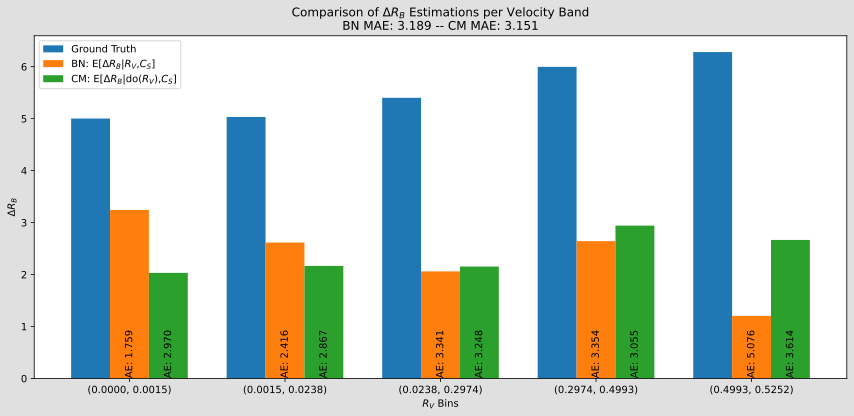

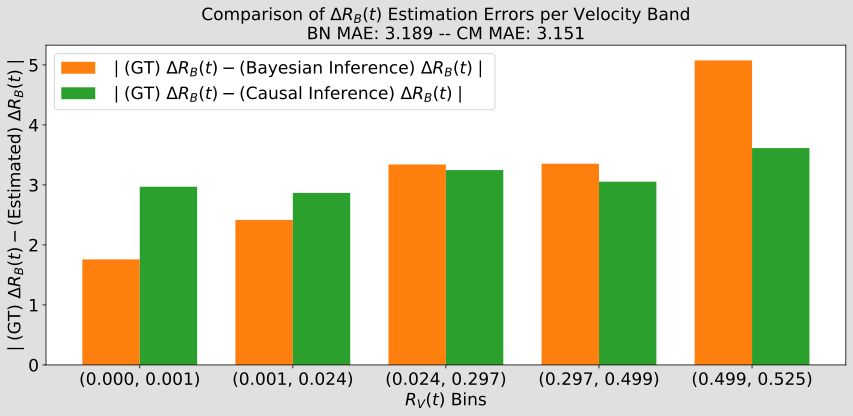

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
STEP = 5
time = 300
gt_noload = []
gt_load = []
gts = []
bayes_preds = []
causal_preds = []

RV_range = midpoints_R_V
for RV_val in RV_range:
    RV_bin_idx = find_bin(RV_val, edges_R_V)
    RV_val = midpoints_R_V[RV_bin_idx]
    GTLOAD = time * (K_l_s + K_l_d * RV_val) 
    GTNOLOAD = time * (K_nl_s + K_nl_d * RV_val)
        
    # --- BN prediction ---
    ie = gum.VariableElimination(bn)
    bn_prior = ie.posterior(target_var)
    evidence = {intervention_var: RV_bin_idx}
    evidence_str = format_evidence_for_latex(evidence)
    ie.setEvidence(evidence)
    ie.makeInference()
    bn_posterior = ie.posterior(target_var)
    bn_posterior_values = bn_posterior.toarray()
    pred_bn = sum(bn_posterior_values[j] * midpoints_EC[j] for j in range(len(bn_posterior_values)))
    bayes_pred = (time/STEP)*pred_bn
        
    # --- CausalModel prediction ---
    formula, adj, exp = pyc.causalImpact(cm, on=target_var, doing=intervention_var, values=evidence)
    posterior_causal = adj.toarray()
    pred_causal = sum(posterior_causal[j] * midpoints_EC[j] for j in range(len(posterior_causal)))
    causal_pred = (time/STEP)*pred_causal
        
    gt_noload.append(GTNOLOAD)
    gt_load.append(GTLOAD)
    gts.append(GTNOLOAD+GTLOAD)
    bayes_preds.append(bayes_pred)
    causal_preds.append(causal_pred)

# Define bar width and offsets
x_indexes = np.arange(len(RV_range))

# Compute absolute errors
cm_errors = np.abs(np.array(causal_preds) - np.array(gts))
bn_errors = np.abs(np.array(bayes_preds) - np.array(gts))

# Compute Mean Absolute Error (MAE)
cm_MAE = np.mean(cm_errors)
bn_MAE = np.mean(bn_errors)


# Plot bars for each category with offset
plt.figure(figsize=(12, 6))
bar_width = 0.25
plt.bar(x_indexes - bar_width, gts, width=bar_width, label="Ground Truth", color='tab:blue', alpha=1)
plt.bar(x_indexes, bayes_preds, width=bar_width, label=r"BN: E[$\Delta R_B$|$R_V$,$C_S$]", color='tab:orange', alpha=1)
plt.bar(x_indexes + bar_width, causal_preds, width=bar_width, label=r"CM: E[$\Delta R_B$|do($R_V$),$C_S$]", color='tab:green', alpha=1)

# Add absolute errors as text at the base of BN and CM bars
for i in range(len(x_indexes)):
    plt.text(x_indexes[i], 0.005, f"AE: {bn_errors[i]:.3f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)
    plt.text(x_indexes[i] + bar_width, 0.005, f"AE: {cm_errors[i]:.3f}", ha='center', va='bottom', fontsize=10, color='black', rotation=90)
    
# Labeling
plt.xlabel(r"$R_V$ Bins")
plt.ylabel(r"$\Delta R_B$")
plt.xticks(x_indexes, [f"({edges_R_V[i-1]:.4f}, {edges_R_V[i]:.4f})" for i in range(1, len(edges_R_V))])  # Format x-axis labels
plt.title(r"Comparison of $\Delta R_B$ " + f"Estimations per Velocity Band\nBN MAE: {bn_MAE:.3f} -- CM MAE: {cm_MAE:.3f}")
plt.legend()
plt.tight_layout()
plt.show()



# Plot bars for each category with offset
plt.figure(figsize=(12, 6))
bar_width = 0.375
plt.bar(x_indexes, bn_errors, width=bar_width, label=r"$\mid (\text{GT})~\Delta R_{B}(t) - (\text{Bayesian Inference})~\Delta R_{B}(t) \mid$", color='tab:orange', alpha=1)
plt.bar(x_indexes + bar_width, cm_errors, width=bar_width, label=r"$\mid (\text{GT})~\Delta R_{B}(t) - (\text{Causal Inference})~\Delta R_{B}(t) \mid$", color='tab:green', alpha=1)
   
# Labeling
plt.xlabel(r"$R_V(t)$ Bins", fontdict={'fontsize': plot_fontsize})
plt.ylabel(r"$\mid (\text{GT})~\Delta R_{B}(t) - (\text{Estimated})~\Delta R_{B}(t) \mid$", fontdict={'fontsize': plot_fontsize})
plt.xticks(x_indexes+bar_width/2, [f"({edges_R_V[i-1]:.3f}, {edges_R_V[i]:.3f})" for i in range(1, len(edges_R_V))], fontdict={'fontsize': plot_fontsize})  # Format x-axis labels
plt.yticks(fontsize=plot_fontsize)  # Format x-axis labels
plt.title(r"Comparison of $\Delta R_B(t)$ " + f"Estimation Errors per Velocity Band\nBN MAE: {bn_MAE:.3f} -- CM MAE: {cm_MAE:.3f}", fontdict={'fontsize': plot_fontsize})
plt.legend(fontsize=plot_fontsize)
plt.tight_layout()

plt.show()


In [ ]:
RV_val = 0.5
distance = 90
time = distance/RV_val
RV_bin_idx = find_bin(RV_val, edges_R_V)
RV_val = midpoints_R_V[RV_bin_idx]
GTLOAD = time * (K_l_s + K_l_d * RV_val) 
GTNOLOAD = time * (K_nl_s + K_nl_d * RV_val)

# --- BN prediction ---
ie = pyAgrum.VariableElimination(bn)
bn_prior = ie.posterior(target_var)
evidence = {intervention_var: RV_bin_idx}
evidence_str = format_evidence_for_latex(evidence)
ie.setEvidence(evidence)
ie.makeInference()
bn_posterior = ie.posterior(target_var)
bn_posterior_values = bn_posterior.toarray()
pred_bn = sum(bn_posterior_values[j] * midpoints_EC[j] for j in range(len(bn_posterior_values)))
bayes_pred = (time/STEP)*pred_bn
        
# --- CausalModel prediction ---
formula, adj, exp = pyc.causalImpact(cm, on=target_var, doing=intervention_var, values=evidence)
posterior_causal = adj.toarray()
pred_causal = sum(posterior_causal[j] * midpoints_EC[j] for j in range(len(posterior_causal)))
causal_pred = (time/STEP)*pred_causal
        
print(f"GT {(GTNOLOAD+GTLOAD)/2:.3f}")
print(f"BN {bayes_pred:.3f} -- AE {np.abs(bayes_pred - (GTNOLOAD+GTLOAD)/2):.3f}")
print(f"CM {causal_pred:.3f} -- AE {np.abs(causal_pred - (GTNOLOAD+GTLOAD)/2):.3f}")

In [ ]:
quantiles_R_V0, edges_R_V0, midpoints_R_V0 = get_info(D, auditDict, 'R_V0')
quantiles_EC0, edges_EC0, midpoints_EC0 = get_info(D, auditDict, 'EC0')

# OBS PRIOR DISTRIBUTION
R_V_selection = D
counts, bins = np.histogram(R_V_selection['OBS0'].values, bins=2)
plt.hist([0, 1], bins, weights=counts/sum(counts), width=0.4, alpha=1, label='OBS')
plt.xticks([0.2, 0.7], ['0', '1'])
plt.xlim([-0.1, 1])
plt.xlabel('OBS')
plt.ylabel(f'p(OBS)')
plt.title(f"Prior Distribution of OBS")
plt.show()

# RV 
RV_val = 0.49
RV_bin_idx = find_bin(RV_val, edges_R_V0)

## OBS GIVEN RV
R_V_selection = D[abs(D['R_V0'] - RV_val) < 0.05]
counts, bins = np.histogram(R_V_selection['OBS0'].values, bins=2)
plt.hist([0, 1], bins, weights=counts/sum(counts), width=0.4, alpha=1, label='OBS')
plt.xticks([0.2, 0.7], ['0', '1'])
plt.xlim([-0.1, 1])
plt.xlabel('OBS')
plt.ylabel(f'p(OBS|RV = {RV_val})')
plt.title(f"Distribution of OBS given RV")
plt.show()

## BC GIVEN RV OBS = 0
OBS_val = 0
ie = pyAgrum.VariableElimination(bn)
bn_prior = ie.posterior(target_var)
evidence = {"R_V0": RV_bin_idx, "OBS0": OBS_val}
evidence_str = format_evidence_for_latex(evidence)
ie.setEvidence(evidence)
ie.makeInference()
bn_posterior = ie.posterior(target_var)
bn_posterior_values = bn_posterior.toarray()
plot_distributions("EC0", [(bn_posterior_values, "")], midpoints_EC0, xlabel="BC", ylabel=f"p(BC|OBS = {OBS_val}, RV = {RV_val})")

## BC GIVEN RV OBS = 1
OBS_val = 1
ie = pyAgrum.VariableElimination(bn)
bn_prior = ie.posterior(target_var)
evidence = {"R_V0": RV_bin_idx, "OBS0": OBS_val}
evidence_str = format_evidence_for_latex(evidence)
ie.setEvidence(evidence)
ie.makeInference()
bn_posterior = ie.posterior(target_var)
bn_posterior_values = bn_posterior.toarray()
plot_distributions("EC0", [(bn_posterior_values, "")], midpoints_EC0, xlabel="BC", ylabel=f"p(BC|OBS = {OBS_val}, RV = {RV_val})")